<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/Regression_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("placement.csv")

In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


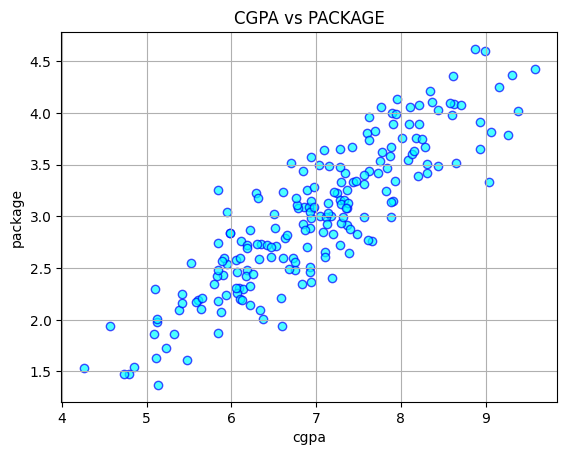

In [6]:
plt.scatter(df['cgpa'],df['package'] , edgecolors='blue', color='cyan',alpha=0.7)
plt.xlabel('cgpa')
plt.ylabel('package')
plt.title("CGPA vs PACKAGE")
plt.grid(True)
plt.show()

In [19]:
X = df.iloc[: ,0:1]
y = df.iloc[:,-1]

In [20]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [21]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [23]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [24]:
lr = LinearRegression()

In [25]:
lr.fit(X_train,y_train)

LinearRegression()

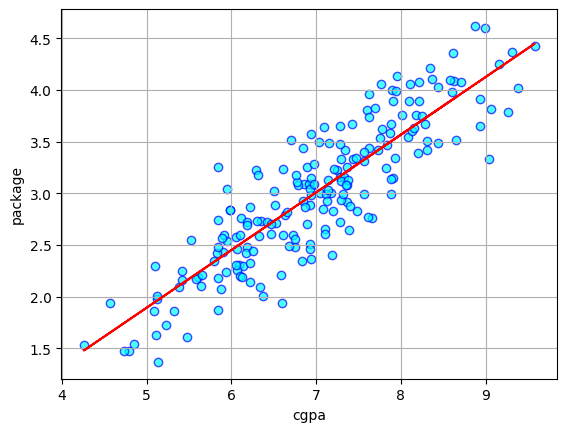

In [28]:
plt.scatter(df['cgpa'],df['package'] , edgecolors='blue', color='cyan',alpha=0.7)
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('cgpa')
plt.ylabel('package')
plt.grid(True)
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
lr.predict(X_test)

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [32]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [33]:
y_pred = lr.predict

In [36]:
y_pred = lr.predict(X_test)
print("MAE", mean_absolute_error(y_test , y_pred))

MAE 0.2884710931878175


In [38]:
print("MSE",mean_squared_error(y_test ,y_pred))

MSE 0.12129235313495527


In [39]:
print("RMSE", np.sqrt(mean_squared_error(y_test , y_pred)))

RMSE 0.34827051717731616


In [41]:
print("R2 Score",r2_score(y_test,y_pred))
r2=r2_score(y_test,y_pred)

R2 Score 0.780730147510384


In [42]:
# Adjusted R2 Score:
X_test.shape

(40, 1)

In [43]:
adjr2 = 1-((1-r2)*(40-1)/(40-1-1))

In [44]:
adjr2

0.7749598882343415

In [47]:
new_df1 = df.copy()
new_df1['Random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','Random_feature','package']]
new_df1.head()

,cgpa,Random_feature,package
0,6.89,0.199769,3.26
1,5.12,0.437708,1.98
2,7.82,0.606734,3.25
3,7.42,0.331157,3.67
4,6.94,0.582002,3.57


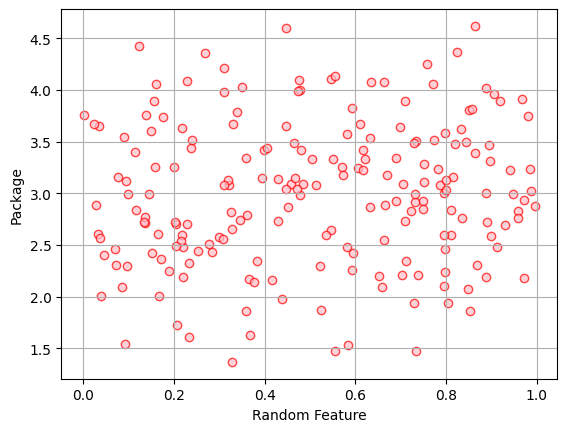

In [48]:
plt.scatter(new_df1['Random_feature'],new_df1['package'], edgecolors='red', color='pink', alpha=0.7)
plt.xlabel('Random Feature')
plt.ylabel('Package')
plt.grid(True)
plt.show()

In [49]:
X = new_df1.iloc[:,0:1]
y = new_df1.iloc[:,-1]

In [50]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [51]:
from sklearn.metrics.pairwise import linear_kernel
lr = LinearRegression()

In [52]:
lr.fit(X_train,y_train)

LinearRegression()

In [53]:
y_pred = lr.predict(X_test)

In [54]:
print("R2 Score", r2_score(y_test,y_pred))
r2 = r2_score(y_test, y_pred)

R2 Score 0.780730147510384


In [55]:
1-((1-r2)*(40-1)/(40-1-2))

0.7688777230514858

In [56]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package']+(np.random.randint(-12,12,200)/10)
new_df2 = new_df2[['cgpa','iq','package']]

In [57]:
new_df2.sample(5)

,cgpa,iq,package
48,8.63,4.19,4.09
193,4.57,1.94,1.94
2,7.82,3.95,3.25
56,5.84,2.44,2.74
8,6.09,2.21,2.31


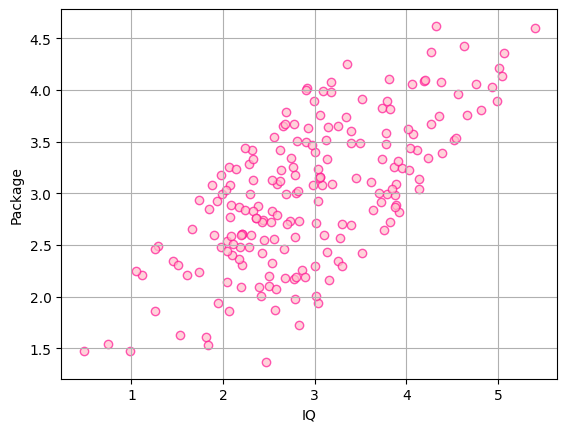

In [63]:
plt.scatter(new_df2['iq'],new_df2['package'], edgecolors='deeppink', color='pink', alpha=0.7)
plt.xlabel('IQ')
plt.ylabel('Package')
plt.grid(True)
plt.show()

In [64]:
np.random.randint(-100,100)

52

In [65]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [67]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [68]:
lr = LinearRegression()

In [69]:
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [70]:
print("R2 Score",r2_score(y_test,y_pred))
r2 = r2_score(y_test, y_pred)

R2 Score 0.8261988243116751


In [71]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8168041661663603